In [ ]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import csv
data = pd.read_csv("posture_data_2.csv")



In [25]:
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(data)
X_embedded.shape

(2000, 2)

TSNE Visualisation

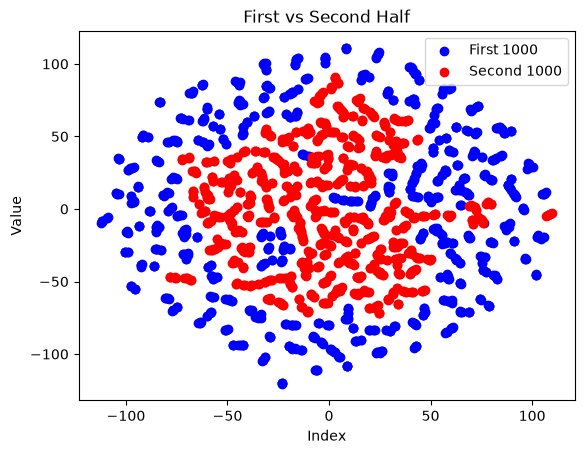

In [26]:
# Split into two parts
df1 = X_embedded[:1000]     # first 1000 rows
df2 = X_embedded[1000:2000] # next 1000 rows

# Plot
plt.scatter(df1[:, 0], df1[:, 1], color='blue', label='First 1000')
plt.scatter(df2[:, 0], df2[:, 1], color='red', label='Second 1000')

plt.legend()
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("First vs Second Half")

plt.show()


Looking at feature differences between high and low positions of the computer 

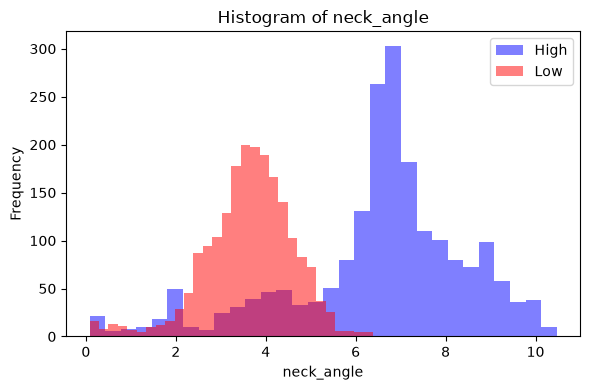

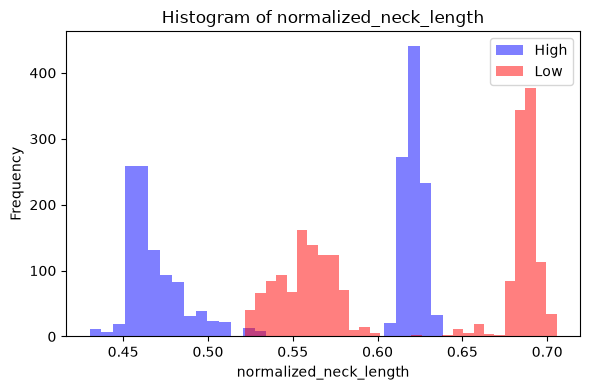

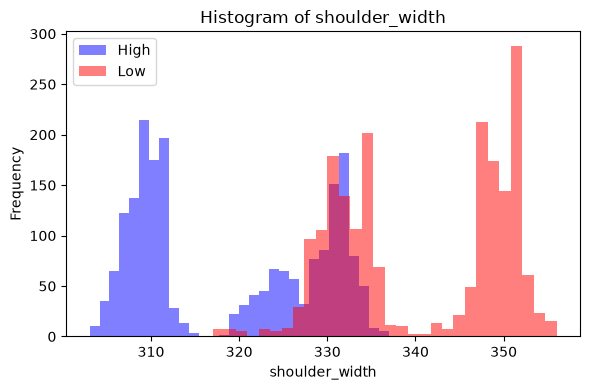

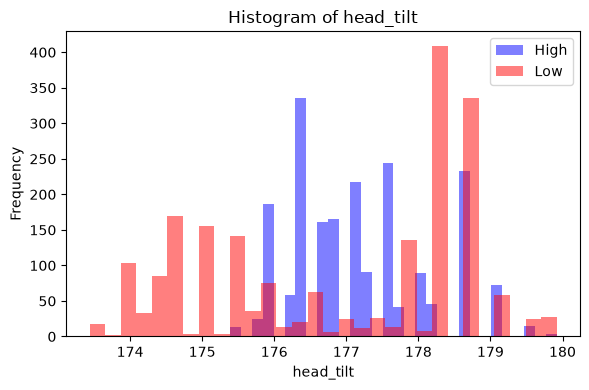

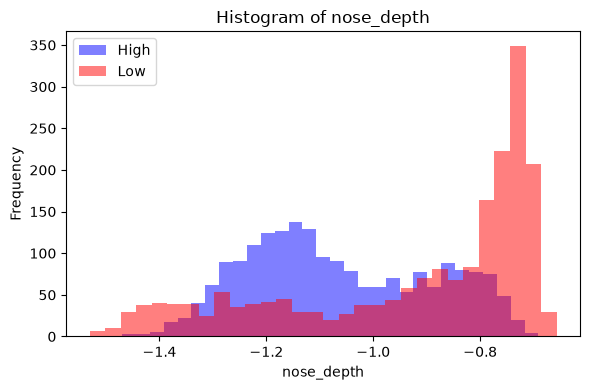

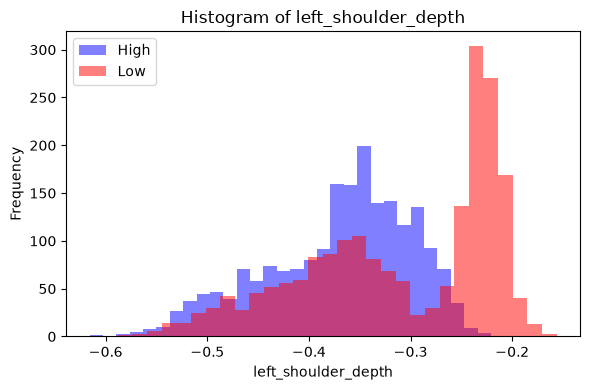

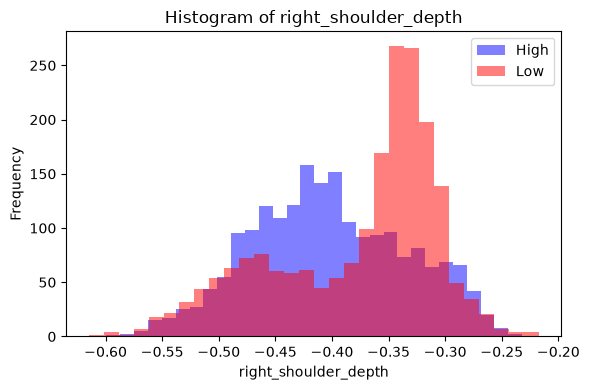

In [ ]:
# Load data
high_posture = pd.read_csv("posture_data_1.csv")
low_posture = pd.read_csv("posture_data_2.csv")

# Loop through each column
for col in high_posture.columns:
    plt.figure(figsize=(6, 4))
    
    # Plot both histograms on the same plot
    plt.hist(high_posture[col], bins=30, alpha=0.5, label='High', color='blue')
    plt.hist(low_posture[col], bins=30, alpha=0.5, label='Low', color='red')
    
    # Labels and title
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # Legend
    plt.legend()
    
    plt.tight_layout()
    plt.show()

Index(['intershoulder_distance', 'necklength_y', 'slouchangle'], dtype='str')


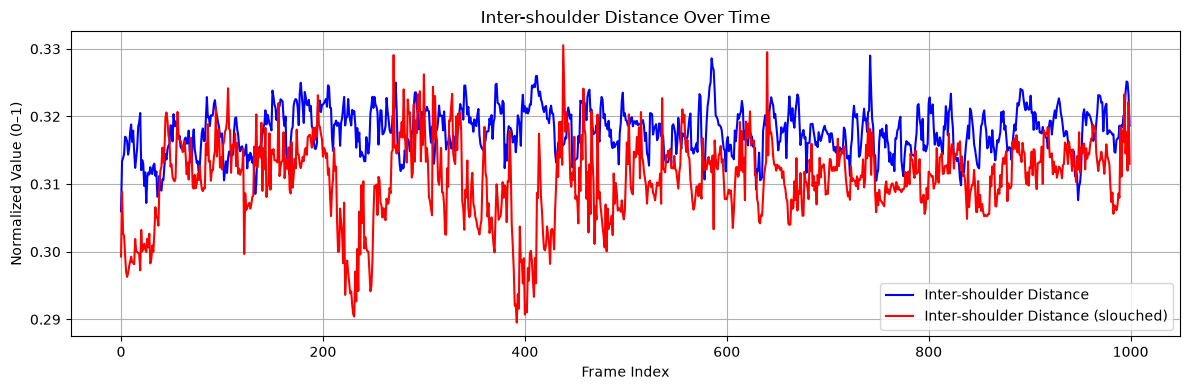

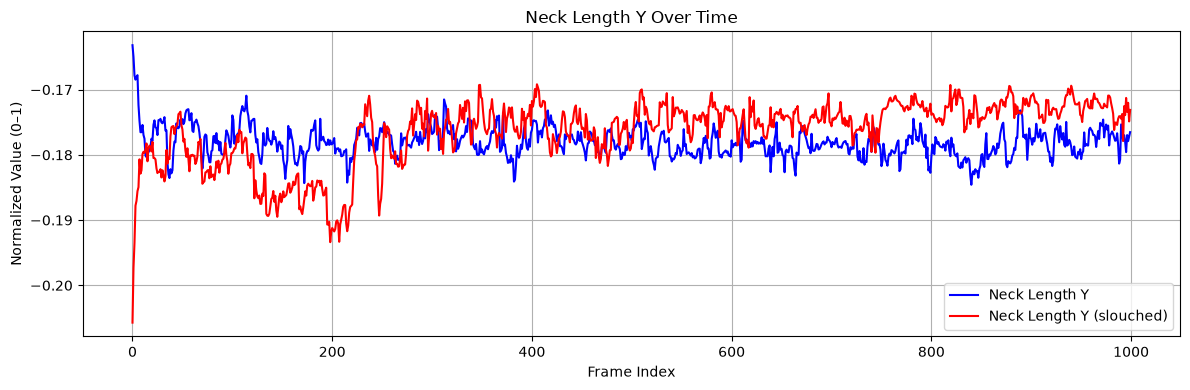

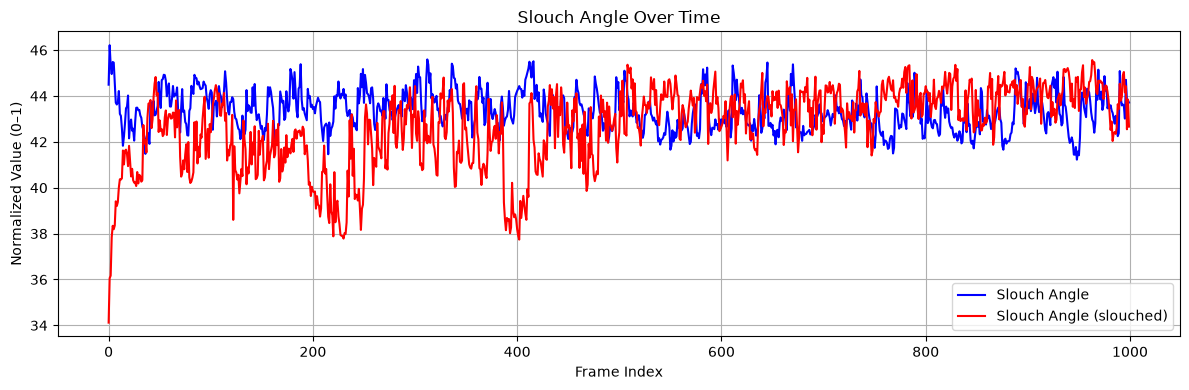

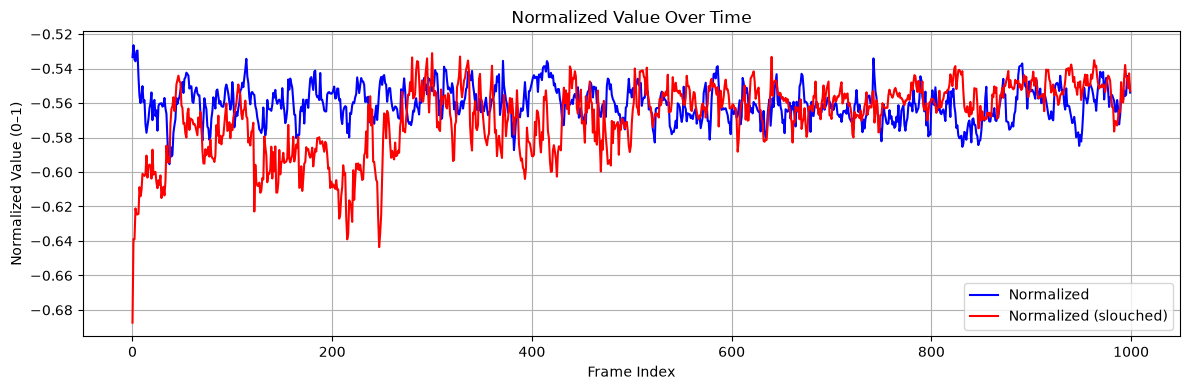

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

data1 = pd.read_csv("posture_data_test.csv")[:1000]
data2 = pd.read_csv("posture_data_test.csv")[1000:2000]
print(data1.columns)
data1["normalized_values"] = data1["necklength_y"]/data1["intershoulder_distance"]
data2["normalized_values"] = data2["necklength_y"]/data2["intershoulder_distance"]
frames = range(len(data1))

data1["prev_avg"] = (
    data1["intershoulder_distance"]
    .rolling(window=50)
    .mean()
)
data2["prev_avg"] = (
    data2["intershoulder_distance"]
    .rolling(window=50)
    .mean()
)


# --- Plot 1: Inter-shoulder Distance ---
plt.figure(figsize=(12, 4))
plt.plot(frames, data1["intershoulder_distance"], label="Inter-shoulder Distance", color="blue")
plt.plot(frames, data2["intershoulder_distance"], label="Inter-shoulder Distance (slouched)", color="red")
plt.xlabel("Frame Index")
plt.ylabel("Normalized Value (0–1)")
plt.title("Inter-shoulder Distance Over Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Neck Length Y ---
plt.figure(figsize=(12, 4))
plt.plot(frames, data1["necklength_y"], label="Neck Length Y", color="blue")
plt.plot(frames, data2["necklength_y"], label="Neck Length Y (slouched)", color="red")
plt.xlabel("Frame Index")
plt.ylabel("Normalized Value (0–1)")
plt.title("Neck Length Y Over Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: Slouch Angle ---
plt.figure(figsize=(12, 4))
plt.plot(frames, data1["slouchangle"], label="Slouch Angle", color="blue")
plt.plot(frames, data2["slouchangle"], label="Slouch Angle (slouched)", color="red")
plt.xlabel("Frame Index")
plt.ylabel("Normalized Value (0–1)")
plt.title("Slouch Angle Over Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 4: Slouch Angle ---
plt.figure(figsize=(12, 4))
plt.plot(frames, data1["normalized_values"], label="Normalized", color="blue")
plt.plot(frames, data2["normalized_values"], label="Normalized (slouched)", color="red")
plt.xlabel("Frame Index")
plt.ylabel("Normalized Value (0–1)")
plt.title("Normalized Value Over Time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [27]:



means_unslouched = {
    "intershoulder_distance": data1["intershoulder_distance"].mean(),
    "necklength_y": data1["necklength_y"].mean(),
    "slouchangle": data1["slouchangle"].mean(),
    "normalized": data1["normalized_values"].mean(),
}

means_slouched = {
    "intershoulder_distance": data2["intershoulder_distance"].mean(),
    "necklength_y": data2["necklength_y"].mean(),
    "slouchangle": data2["slouchangle"].mean(),
    "normalized": data2["normalized_values"].mean(),
}

print("Unslo​​uched Means:", means_unslouched)
print("Slouched Means:", means_slouched)



Unslo​​uched Means: {'intershoulder_distance': np.float64(0.3177742634496363), 'necklength_y': np.float64(-0.1780656549781561), 'slouchangle': np.float64(43.33635231715367), 'normalized': np.float64(-0.5604290292459793)}
Slouched Means: {'intershoulder_distance': np.float64(0.31066502600703233), 'necklength_y': np.float64(-0.1765162937939167), 'slouchangle': np.float64(42.68706251526435), 'normalized': np.float64(-0.5684301182331792)}


In [8]:
top5 = data1["intershoulder_distance"].nsmallest(5)
print(top5)


654    0.244256
265    0.246226
299    0.246283
261    0.249553
652    0.250379
Name: intershoulder_distance, dtype: float64


In [9]:
top5 = data2["intershoulder_distance"].nsmallest(5)
print(top5)

1515    0.275524
1520    0.276922
1342    0.277530
1513    0.277924
1346    0.278551
Name: intershoulder_distance, dtype: float64
